
# **DINOv3 SAT** K-Means

Este cuaderno usa **DINOv3 preentrenado en satélite (SAT‑493M)** para extraer embeddings y agrupar **las primeras 100 parcelas** de un `FeatureCollection` en Google Earth Engine (GEE) del año **2019**.

**Pipeline:**
1) Carga de *FeatureCollection* (primeras 100).
2) Mosaico **Sentinel‑2** 2019 con máscara simple de nubes.
3) Extracción de *patches* RGB 224×224 por parcela.
4) **Embeddings con DINOv3 SAT** (Hugging Face Transformers).  
   - Fallback opcional vía `timm` si no se tiene acceso a los pesos con *gating*.
5) **K‑Means (k=19)** y visualización.
6) Inspección de una parcela (imagen + cluster + vecinos similares).


## 2) Imports y autenticación con Earth Engine

In [ ]:

import os, json, math
from pathlib import Path
from typing import Optional, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ee
import geemap
from PIL import Image

import torch
from tqdm import tqdm

# ML
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# --- Inicializar Earth Engine 
try:
    ee.Initialize(project='fonseca-472504') 
except Exception:
    ee.Authenticate()
    ee.Initialize()

print('EE listo ✅')


EE listo ✅


## 3) Configuración

In [ ]:

ASSET_FC = 'projects/fonseca-472504/assets/pastis_parcels_wkt'
YEAR = 2019
N_PARCELS = 100

# Patches
SCALE = 10                 # m/px para S2
PATCH_SIDE_METERS = 2240   # 224 px a 10 m/px
BANDS = ['B4','B3','B2']   # RGB

# Salidas
OUT_DIR = Path('../dinov3/dinov3')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Clustering
N_CLUSTERS = 19
RANDOM_STATE = 42

# Inspección
SELECT_INDEX = 0 


Preproceso S2, mosaico anual y extracción a NumPy (alto nivel)

- **Enmascara nubes** en Sentinel-2 SR (L2A) con **SCL** conservando píxeles de vegetación, suelo, agua y (opcional) nubes prob. baja.
- **Construye un mosaico anual** (mediana) sobre una geometría dada, **selecciona `BANDS`** y **escala** reflectancias a **[0..1]**.
- **Genera parches cuadrados** centrados en un AOI (`square_bbox_around`) para muestrear de forma consistente.
- **Convierte una `ee.Image` a NumPy** (`H×W×C`, `float32`, `[0..1]`) con validaciones de forma y saneo de `NaN`.

- **Calidad y estabilidad**: el enmascarado + mediana reduce ruido temporal (nubes/sombras) y valores atípicos.
- **Reproducibilidad**: fija un flujo claro *mask → select → median → clip → scale*; los parches resultan comparables entre AOIs y corridas.
- **Interoperabilidad**: llevar parches a **NumPy** permite usar librerías locales (ML/embeddings/visualización) manteniendo el mismo contenido que en EE.

### Conceptos clave
- **SCL (L2A)**: banda de clasificación de escena; incluir clase **7 (cloud low prob.)** es **permisivo** y puede dejar algo de nube; para ser estricto, exclúyela.
- **Orden de operaciones**: filtrar por AOI/fecha → **mask SCL** → `select(BANDS)` → `median()` → `clip(geom)` → **/10000** a `[0..1]`.
- **Resolución/CRS**: S2 mezcla 10/20/60 m; EE remuestrea implícitamente al combinar. Si necesitas **alineación píxel a píxel** (p. ej., con etiquetas L93), **reprojeta** antes de reducir/exportar.
- **Parches cuadrados**: `centroid → buffer(side/2) → bounds()` produce un **bbox** estable en metros (aprox.); para rigor cartográfico, usa un CRS métrico apropiado.
- **NumPy**: `geemap.ee_to_numpy` devuelve `NaN` en píxeles enmascarados; aquí se **sanean a 0.0** y se **recortan** a `[0,1]`. Se valida `(H,W,C)` y que `C == len(BANDS)`; si no, retorna `None`.
- **Rendimiento**: regiones grandes a `scale=10` m pueden ser pesadas; usa **bboxes** pequeños y evita traer datos innecesarios.



In [5]:

def mask_s2_sr_clouds(img: ee.Image) -> ee.Image:
    """Máscara simple usando SCL (L2A)."""
    scl = img.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))  # veg, bare, water, unclassified
    return img.updateMask(good)

def s2_mosaic_annual(geom: ee.Geometry, year: int) -> ee.Image:
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year+1, 1, 1)
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(geom)
           .filterDate(start, end)
           .map(mask_s2_sr_clouds)
           .select(BANDS))
    mosaic = col.median().clip(geom)
    return mosaic.divide(10000).rename(BANDS)  # [0..1]

def square_bbox_around(geom: ee.Geometry, side_m: float) -> ee.Geometry:
    c = geom.centroid(1)
    half = side_m / 2.0
    return c.buffer(half).bounds()

def ee_to_numpy_patch(img: ee.Image, region: ee.Geometry, scale: int = 10) -> Optional[np.ndarray]:
    """Devuelve (H,W,C) float32 [0..1] o None."""
    try:
        arr = geemap.ee_to_numpy(img, region=region, bands=BANDS, scale=scale)
        if arr is None or arr.ndim != 3 or arr.shape[2] != len(BANDS):
            return None
        arr = np.nan_to_num(arr, nan=0.0)
        arr = np.clip(arr, 0.0, 1.0).astype(np.float32)
        return arr
    except Exception as e:
        print("ee_to_numpy_patch error:", e)
        return None


## Extracción masiva de *patches* S2 a PNG (224×224) + índice CSV

- Carga una **FeatureCollection** (`ASSET_FC`) y toma las primeras `N_PARCELS` features.
- Para cada parcela:
  1) Obtiene su **geometría** (`geom`) y construye un **mosaico anual** S2 (mediana) con máscara SCL vía `s2_mosaic_annual(geom, YEAR)`.  
  2) Define un **bbox cuadrado** centrado en la parcela de lado `PATCH_SIDE_METERS` (`square_bbox_around`).  
  3) **Extrae** el parche como **NumPy** `(H,W,C)` con `ee_to_numpy_patch(img, region, scale=SCALE)` en `[0..1]`.  
  4) Convierte a **PIL** (uint8 0–255), **redimensiona a 224×224** (para modelos tipo ViT/DINO) y **guarda** `parcel_XXXX.png` en `OUT_DIR`.  
  5) Lee **propiedades** del feature y las guarda (JSON) junto con el índice y la ruta del archivo.
- Al final, crea un **CSV índice** `parcels_index.csv` con columnas: `parcel_index`, `file`, `properties`.

- Genera un **dataset visual estandarizado** (224×224) listo para **modelos de visión** (p. ej., ViT/DINO/DINOv2/CLIP) sin depender del backend de EE en tiempo de entrenamiento.
- Mantiene la **trazabilidad**: cada PNG se enlaza a sus **metadatos originales** (en `properties`), facilitando análisis posteriores (región, fecha, clase, etc.).
- Permite **iterar rápido**: con `tqdm` y extracción local/ligera puedes evaluar prototipos de *embeddings* y clasificadores sin largos *exports*.

### Conceptos clave
- **Orden de la FC**: `fc.toList(N_PARCELS)` usa el orden natural; para **reproducibilidad**, considera `fc.sort('system:index')` (o una propiedad propia) **antes** del `toList`.
- **BANDS y PIL**: `Image.fromarray(...)` admite **1** (grayscale) o **3/4** canales. Asegúrate de que `BANDS` sean **3 bandas** (p. ej., `['B4','B3','B2']`) o **sintetiza** RGB (ej. PCA/índices). Si `C≠1/3/4`, la conversión fallará.
- **Escala/CRS**: `scale=SCALE` (p. ej., 10 m) controla la resolución del parche. Si necesitas alineación con otra rejilla (p. ej., L93 de etiquetas), **reprojeta** antes de muestrear.
- **Normalización**: `ee_to_numpy_patch` devuelve `[0..1]`; al convertir a 8 bits se **cuantiza** a 0–255. Para **modelos sensibles** a la radiometría, considera **guardar .npy** además del PNG para conservar **float32**.
- **BBox cuadrado**: `square_bbox_around` puede incluir áreas **fuera** del polígono; es útil para estandarizar el contexto alrededor de la parcela (consistente entre samples).
- **Metadatos**: `properties` se guardan como **JSON**; si necesitas análisis tabular, **aplána** las claves a columnas (p. ej., con `pandas.json_normalize`).

In [6]:

fc = ee.FeatureCollection(ASSET_FC)
fc_list = fc.toList(N_PARCELS)

records: List[Dict] = []
images: List[Image.Image] = []
filenames: List[str] = []

from torchvision.transforms import Resize
resize_224 = Resize((224, 224))

for i in tqdm(range(N_PARCELS), desc='Extrayendo patches'):
    feat = ee.Feature(fc_list.get(i))
    geom = feat.geometry()
    img = s2_mosaic_annual(geom, YEAR)
    region = square_bbox_around(geom, PATCH_SIDE_METERS)
    np_patch = ee_to_numpy_patch(img, region, scale=SCALE)
    if np_patch is None:
        print(f"[WARN] Saltando índice {i} (patch None)")
        continue

    # PIL y resize a 224
    pil_img = Image.fromarray((np_patch * 255).astype(np.uint8))
    pil_img = resize_224(pil_img)

    fn = OUT_DIR / f"parcel_{i:04d}.png"
    pil_img.save(fn)
    filenames.append(str(fn))
    images.append(pil_img)

    try:
        props = ee.Feature(feat).toDictionary().getInfo()
    except Exception:
        props = {}

    records.append({'parcel_index': i, 'file': str(fn), 'properties': json.dumps(props)})

df_parcels = pd.DataFrame.from_records(records)
df_parcels.to_csv(OUT_DIR / "parcels_index.csv", index=False)
print("Guardados:", len(images), "patches en", str(OUT_DIR))


Extrayendo patches: 100%|██████████| 100/100 [14:43<00:00,  8.83s/it]

Guardados: 100 patches en ..\dinov3\dinov3


## Cargar DINOv3-SAT local con `timm` (pesos en disco) y dejar listo para extraer *embeddings*

- **Configura el dispositivo** (`cuda` si hay GPU, si no `cpu`) y **crea** un modelo **ViT-Large/16 DINOv3** desde `timm` **sin pesos**.
- **Carga** un archivo de **pesos locales** (`.pth/.bin/.safetensors`) en el `state_dict` del modelo con `strict=False`.
- **Desactiva la cabeza de clasificación** (`reset_classifier(0)`) para usar el modelo como **extractor de *embeddings***.
- **Pone** el modelo en **modo evaluación** (`eval()`) y **registra** el **tamaño del embedding** (`emb_dim`, p. ej., 1024 para ViT-L/16).
- **Intenta** crear el **pipeline de *transforms*** alineado al **preset SAT** de `timm`; si no está disponible en tu versión, deja `trans=None` para que lo definas manualmente después.

- Permite usar **DINOv3-SAT** **offline** (sin internet) y con **control total** sobre los pesos: ideal para entornos **restringidos** o **reproducibles**.
- Eliminar la cabeza y fijar `eval()` asegura que obtendrás **representaciones estables** (sin *dropout*/BN en entrenamiento), listas para:
  - **clustering no supervisado** (K-means),
  - **retrieval**/búsqueda semántica,
  - **clasificación ligera** aguas abajo (p. ej., RF/SVM),
  - **inyección** de vectores a un LLM.
- Usar el **preset SAT** (cuando está) te da **normalización/tamaño** consistentes con el **pre-entrenamiento satelital**, mejorando la **compatibilidad** entre datos y pesos.

### Conceptos clave
- **Arquitectura**: `vit_large_patch16_dinov3` = ViT-L con *patch* de **16 px**. Por convención, entrada **224×224** (se puede cambiar, pero respeta múltiplos de 16).
- **Pesos locales**:  
  - `.safetensors` → se cargan con `safetensors.torch.load_file`.  
  - `.pth/.bin` → `torch.load(..., map_location='cpu')`.  
  - `strict=False` permite que **falte** la cabeza o haya **claves extra** sin romper la carga.
- **`reset_classifier(0)`**: elimina capas finales de clasificación → **solo features**. Para extraer embeddings, usa `model.forward_features(x)` o el *forward* y toma el **token CLS**/**pooled** según implemente `timm`.
- **`emb_dim = model.num_features`**: dimensión del vector de salida (p. ej., **1024** en ViT-L/16 DINOv3).
- **Transforms SAT**: `resolve_model_data_config` + `create_transform` intentan traer **size/crop/mean/std** del preset `sat_493m`. Si no está, define manualmente:  
  - **Resize/Crop** a **224** (centrado),  
  - **ToTensor**,  
  - **Normalize** con *mean/std* del preset SAT (si no lo tienes, usa las de ImageNet como aproximación y documenta la diferencia).
- **Performance**: usar `with torch.inference_mode():` y, si hay GPU reciente, **FP16** (`x.half(); model.half()`) y **channels_last** (`.to(memory_format=torch.channels_last)`) puede acelerar.



In [ ]:

# === CARGAR DINOv3 SAT LOCAL ===
import os, torch, timm
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1) Ruta a tu archivo de pesos local (.safetensors / .pth / .bin)
#    🔧 EDITA ESTA RUTA:
LOCAL_WEIGHTS = "../pretrained_models/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"

# 2) Crear el modelo base ViT-L/16 DINOv3 (sin pesos)
model = timm.create_model('vit_large_patch16_dinov3', pretrained=False)
model.reset_classifier(0)

# 3) Cargar el state_dict desde archivo
if LOCAL_WEIGHTS.endswith(".safetensors"):
    from safetensors.torch import load_file
    state = load_file(LOCAL_WEIGHTS)
else:
    state = torch.load(LOCAL_WEIGHTS, map_location='cpu')

missing, unexpected = model.load_state_dict(state, strict=False)
print(f"[LOAD] missing={len(missing)} | unexpected={len(unexpected)}  (algunas claves pueden ser normales)")

model = model.to(device).eval()
model_name_used = "DINOv3-SAT local (timm)"
emb_dim = getattr(model, "num_features", 1024)

# 4) Transforms alineados al preset SAT de timm
#    Si tu timm soporta el preset, estas líneas crearán la normalización adecuada.
try:
    data_cfg = timm.data.resolve_model_data_config(
        model, pretrained_cfg='hf_hub:timm/vit_large_patch16_dinov3.sat_493m'
    )
    trans = timm.data.create_transform(**data_cfg, is_training=False)
    print("[OK] Transform SAT de timm activado.")
except Exception as e:
    trans = None
    print("[INFO] Transform SAT no disponible en tu timm; se usará el transform por defecto en la celda de embeddings.")

# 5) Señalizar que NO usamos processor HF
processor = None
print("[OK]", model_name_used, "| emb_dim:", emb_dim)


C:\Users\LuisA\AppData\Local\Temp\ipykernel_18824\2959000903.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(LOCAL_WEIGHTS, map_location='cpu')


[LOAD] missing=49 | unexpected=101  (algunas claves pueden ser normales)
[INFO] Transform SAT no disponible en tu timm; se usará el transform por defecto en la celda de embeddings.
[OK] DINOv3-SAT local (timm) | emb_dim: 1024


## Extraer *embeddings* con DINOv3-SAT en lotes (timm u opción HF), guardar `.npy` y enlazar al índice

- **Itera en lotes** (`batch_size`) sobre la lista de imágenes `images` (PIL 224×224) y obtiene sus **vectores de embedding**:
  - **Ruta HF (si `processor` ≠ `None`)**: usa el *processor* de Transformers para crear tensores y toma `outputs.pooler_output` → matriz `(B, D)`.
  - **Ruta timm (Opción B)**: asegura un **transform** (`trans`) compatible con el modelo; hace `model.forward_features(tens)` y extrae el **token CLS**/**pool** como embedding `(B, D)`.
- **Concatena** todos los lotes en un arreglo `emb` de forma `(N, emb_dim)`.
- **Guarda** los embeddings en `embeddings_dinov3sat.npy`.
- **Actualiza** `parcels_index.csv` agregando la columna `emb_idx` para mapear cada fila a su vector en `emb`.

- **Eficiencia**: procesar en **lotes** saca provecho de GPU/CPU y evita desbordar memoria.
- **Compatibilidad**: admite tanto el flujo **Transformers** (cuando se usa `processor`) como la ruta **timm** (pesos locales, sin internet).
- **Trazabilidad**: la columna `emb_idx` conecta **cada PNG** con su **vector** en el `.npy`, facilitando búsquedas, clustering y entrenamiento posterior sin re-embeddear.

### Conceptos clave
- **Embeddings**: vectores densos de dimensión `emb_dim` (p. ej., **1024** en ViT-L/16 DINOv3) que resumen la semántica visual del parche.
- **Transforms**:
  - En **HF**, el `processor` maneja *resize/normalize* internamente.
  - En **timm**, `trans` debe incluir **resize/crop a 224**, **ToTensor** y **Normalize** (idealmente el **preset SAT**); si no existe, se resuelve con `resolve_model_data_config` / `create_transform`.
- **Pooling / token CLS**:
  - En HF: `pooler_output` ya es el embedding.
  - En timm: `forward_features` puede devolver un **dict**; se toma `pool` o `x_norm_clstoken` (o el último tensor), y si tiene forma `(B, T, D)` se usa el **token 0** (CLS).
- **Sin gradientes**: `torch.inference_mode()` evita autograd, reduce memoria y acelera la inferencia.
- **Persistencia**:
  - `embeddings_dinov3sat.npy` almacena todos los vectores `(N, D)` en `float32`.
  - `parcels_index.csv` se reescribe con `emb_idx = 0..N-1`.

In [10]:

import numpy as np
from torchvision import transforms as T
import torch

emb_list = []
batch_size = 8  # ajusta según tu GPU/CPU

if processor is not None:
    # Ruta Transformers (no usada en Opción B)
    def iter_batches(img_list, n):
        for i in range(0, len(img_list), n):
            yield img_list[i:i+n]
    for batch_imgs in tqdm(list(iter_batches(images, batch_size)), desc='Embeddings (HF)'):
        inputs = processor(images=batch_imgs, return_tensors="pt").to(device)
        with torch.inference_mode():
            outputs = model(**inputs)
        z = outputs.pooler_output  # (B, D)
        emb_list.append(z.cpu().numpy())
else:
    # Ruta timm (Opción B)
    import timm
    # Si 'trans' viene del loader, úsalo; si no, crea uno por defecto
    try:
        trans
        if trans is None:
            raise NameError
    except NameError:
        data_cfg = timm.data.resolve_model_data_config(model)
        trans = timm.data.create_transform(**data_cfg, is_training=False)

    def iter_batches(img_list, n):
        for i in range(0, len(img_list), n):
            yield img_list[i:i+n]
    for batch_imgs in tqdm(list(iter_batches(images, batch_size)), desc='Embeddings (timm)'):
        tens = torch.stack([trans(img).to(device) for img in batch_imgs])
        with torch.inference_mode():
            feats = model.forward_features(tens)
            if isinstance(feats, dict):
                x = feats.get('pool', None)
                if x is None:
                    x = feats.get('x_norm_clstoken', None)
                    if x is None:
                        x = list(feats.values())[-1]
            else:
                x = feats
            if x.ndim == 3 and x.shape[1] >= 1:  # tokens
                x = x[:, 0, :]
        emb_list.append(x.detach().cpu().numpy())

emb = np.concatenate(emb_list, axis=0) if emb_list else np.zeros((0, emb_dim or 1024), dtype=np.float32)
print("Embeddings:", emb.shape)
np.save(OUT_DIR / "embeddings_dinov3sat.npy", emb)

df_parcels = pd.read_csv(OUT_DIR / "parcels_index.csv")
df_parcels['emb_idx'] = np.arange(len(emb))
df_parcels.to_csv(OUT_DIR / "parcels_index.csv", index=False)
df_parcels.head()


Embeddings (timm): 100%|██████████| 13/13 [00:05<00:00,  2.26it/s]

Embeddings: (100, 1024)


,parcel_index,file,properties,emb_idx
0,0,..\dinov3\dinov3\parcel_0000.png,"{""patch_id"": 10000}",0
1,1,..\dinov3\dinov3\parcel_0001.png,"{""patch_id"": 10001}",1
2,2,..\dinov3\dinov3\parcel_0002.png,"{""patch_id"": 10002}",2
3,3,..\dinov3\dinov3\parcel_0003.png,"{""patch_id"": 10003}",3
4,4,..\dinov3\dinov3\parcel_0004.png,"{""patch_id"": 10004}",4


## Agrupar parcelas con K-means sobre *embeddings* DINOv3-SAT y resumir distribución

- **Verifica integridad**: asegura que existe al menos una fila en `df_parcels` y que el número de *embeddings* guardados en `embeddings_dinov3sat.npy` **coincide** con las filas del índice (`assert`).
- **Carga** los *embeddings* `emb ∈ ℝ^{N×D}` desde disco.
- **Ajusta K-means** con `n_clusters = N_CLUSTERS`, `random_state = RANDOM_STATE` y `n_init = 10`, y obtiene las **etiquetas de cluster** (`labels`).
- **Anexa** `cluster` al `DataFrame` (`df_parcels`) y **exporta** `parcels_clusters.csv`.
- **Imprime** el conteo por cluster (`np.bincount(labels)`) y **grafica** un histograma de la **distribución de parcelas por cluster**.

- Ofrece una **visión no supervisada** de la estructura en el espacio de *embeddings*; ayuda a:
  - detectar **grupos naturales** (p. ej., tipos de cultivo/uso de suelo),
  - **priorizar** etiquetado/validación por grupos,
  - **muestrear balanceado** por cluster,
  - usar los clusters como **pseudolabels** o como *features* adicionales en modelos supervisados.
- Sirve como **sanity check** de los *embeddings*: si todos los puntos caen en 1–2 clusters, quizá falten variaciones o haya problemas de preproceso.

### Conceptos clave
- **Reproducibilidad**: fija `random_state` y un `n_init` explícito para resultados estables entre corridas (K-means es sensible a la inicialización).
- **Normalización**: para *embeddings* tipo DINO, suele convenir **L2-normalizar** filas (`emb /= ||emb||`) antes de K-means (Euclídea sobre vectores normalizados ≈ **cosine K-means**).
- **Dimensionalidad**: en espacios grandes (p. ej., D=1024), considera **PCA a 32–128** componentes **antes** de K-means para estabilizar y acelerar (sin perder estructura gruesa).
- **Elección de K**:
  - **A priori**: igualar a las clases esperadas (p. ej., `K=19` si PASTIS).
  - **Empírico**: **codo (inercia)**, **silhouette**, **Davies–Bouldin**; repite con varios K y compara.
- **Interpretación**:
  - K-means asume **clusters convexos** y **distancia Euclídea**; no garantiza equivalencia 1:1 con **clases semánticas**.
  - Para mapear clusters→clases (si tienes GT), usa **asignación húngara** sobre la matriz de confusión (post-hoc).
  - Clusters **muy desbalanceados** pueden indicar outliers o elección de K subóptima.
- **Escalabilidad**: si `N` es grande, usa **MiniBatchKMeans** para reducir coste (mantén semillas y `batch_size` fijos).
- **Persistencia**: `parcels_clusters.csv` te permite **reutilizar** agrupaciones sin recalcular K-means (útil para análisis en mapas o dashboards).



Exception in thread Thread-9 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\LuisA\.conda\envs\dinov3\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\LuisA\.conda\envs\dinov3\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\LuisA\.conda\envs\dinov3\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\LuisA\.conda\envs\dinov3\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\LuisA\.conda\envs\dinov3\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 115: invalid start byte


Clusters asignados con DINOv3 SAT: [13  1 12  4  1  6 20  1  2 14  5  1  4  1  5  1  7  1  1]


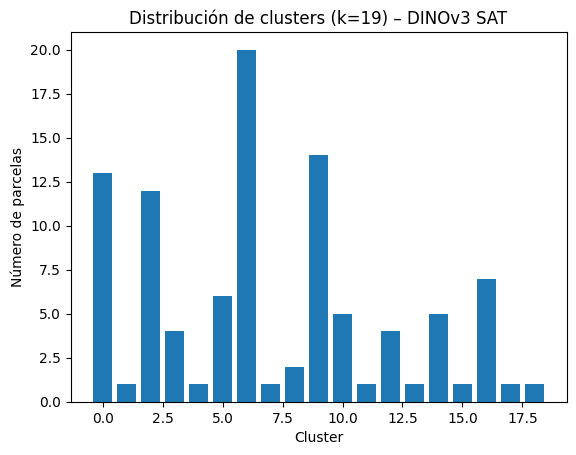

In [11]:

assert len(df_parcels) > 0 and np.load(OUT_DIR / "embeddings_dinov3sat.npy").shape[0] == len(df_parcels), \
    "No hay embeddings o índice inconsistente."

emb = np.load(OUT_DIR / "embeddings_dinov3sat.npy")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(emb)
df_parcels['cluster'] = labels
df_parcels.to_csv(OUT_DIR / "parcels_clusters.csv", index=False)
print("Clusters asignados con DINOv3 SAT:", np.bincount(labels))

plt.figure()
plt.title("Distribución de clusters (k=19) – DINOv3 SAT")
unique, counts = np.unique(labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Cluster")
plt.ylabel("Número de parcelas")
plt.show()


## Búsqueda de vecinos similares por *embedding* dentro del mismo cluster (inspección cualitativa)

- **Valida** que `SELECT_INDEX` esté dentro del rango del `DataFrame` (`assert`).
- **Recupera** la fila de la parcela seleccionada (`row`), su **ruta de imagen** y el **cluster** asignado por K-means.
- **Muestra** la imagen de la parcela seleccionada.
- **Filtra** los índices de todas las parcelas en el **mismo cluster** (`same_cluster_idx`).
- **Carga** los *embeddings* (`embeddings_dinov3sat.npy`) y calcula la **similitud de coseno** entre la parcela seleccionada y el resto del **mismo cluster**.
- **Ordena** por mayor similitud (omitendo el propio índice) y **visualiza** las **6 más similares** en una grilla (mini-galería).

- Proporciona una **auditoría cualitativa** del agrupamiento: comprueba si los elementos dentro de un cluster son realmente **visualmente/semánticamente afines**.
- Permite **interpretar** el espacio de *embeddings* (DINOv3-SAT): si los vecinos “se parecen” en textura/estructura/espectro, el *embedding* está capturando patrones útiles.
- Sirve como **herramienta de curación**: detectar **outliers** o **errores** de extracción/etiquetado dentro de un cluster, y priorizar revisiones.

### Conceptos clave
- **Similitud de coseno**: mide el **ángulo** entre vectores; si los *embeddings* están **L2-normalizados**, la similitud de coseno ≡ **producto punto**. Úsala para comparar vectores de distinta magnitud.
- **Cluster-aware retrieval**: buscar vecinos **dentro** del mismo cluster evita “falsos parecidos” inter-cluster y ayuda a evaluar la **coherencia intra-cluster**.
- **Exclusión del propio elemento**: se omite el índice de la parcela consultada (`order[1:7]`) para no devolverse a sí misma.
- **Visual sanity check**: ver las 6 más similares rápidamente revela **patrones comunes** (orientación de surcos, coloración, textura) o **inconsistencias**.



Parcela idx=0 | Cluster=12 | Archivo=..\dinov3\dinov3\parcel_0000.png | Modelo: DINOv3-SAT local (timm)


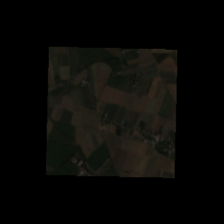

Más similares (mismo cluster): [np.int64(47), np.int64(86), np.int64(12)]


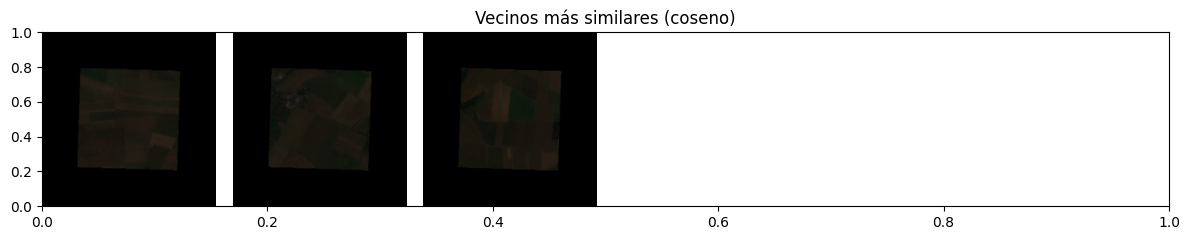

In [12]:

assert SELECT_INDEX < len(df_parcels), "SELECT_INDEX fuera de rango."
row = df_parcels.iloc[SELECT_INDEX]
img_path = row['file']
cl = int(row['cluster'])

print(f"Parcela idx={SELECT_INDEX} | Cluster={cl} | Archivo={img_path} | Modelo: {model_name_used}")
display(Image.open(img_path))

# Vecinos en el mismo cluster por coseno
same_cluster_idx = np.where(df_parcels['cluster'].values == cl)[0]
emb = np.load(OUT_DIR / "embeddings_dinov3sat.npy")

if len(same_cluster_idx) > 1:
    sims = cosine_similarity(emb[SELECT_INDEX][None, :], emb[same_cluster_idx]).ravel()
    order = np.argsort(-sims)
    top = [same_cluster_idx[j] for j in order[1:7]]  # omite el propio
    print("Más similares (mismo cluster):", top)
    plt.figure(figsize=(12, 2.5))
    plt.title("Vecinos más similares (coseno)")
    for i, idx in enumerate(top[:6]):
        ax = plt.subplot(1, 6, i+1)
        ax.imshow(Image.open(df_parcels.iloc[idx]['file']))
        ax.axis('off')
        ax.set_xlabel(f"#{idx}")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes elementos en este cluster para vecinos similares.")
